In [1]:
from llms.llm_ochestrator import LLMOchestrator
config_name = "gpt2-small-1024"
model_type = "basic"
ochestrator = LLMOchestrator(config_name, model_type)

ochestrator.model_config

{'vocab_size': 50257,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'model_name': 'gpt2-small-1024',
 'model_size': '124M',
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12,
 'context_length': 1024}

In [2]:
ochestrator.model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [3]:
print(ochestrator.generate_text(start_context="Every moves you",
                          max_new_tokens=25))

Every moves you fest planned formed studied DiseasessudoihilShadowFinallyearcher pharmacies outdooricomember libraries certWorld CyrHeader 1888 THERE possibilitycourt Africa reminder


In [4]:
ochestrator.load_weight()

In [5]:
print(ochestrator.generate_text(start_context="Every effort moves you",
                          max_new_tokens=15))

Every effort moves you forward.

The first step is to understand the importance of your work


In [6]:
# ochestrator.load_model("./trained_models/gpt2-small-1024-(124M)-classification.pth")

In [7]:
import torch
torch.manual_seed(123)
base_path = "./training_data/sms_spam_collection/"
train_loader, val_loader, test_loader = ochestrator.create_spamdata_dataloader(train_file_path=base_path+"train.csv",
                                       val_file_path=base_path+"validation.csv",
                                       test_file_path=base_path+"test.csv",
                                       batch_size=8, 
                                       shuffle=True                                      
                                       )


In [8]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [9]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


In [10]:
torch.manual_seed(123)
num_classes = 2
ochestrator.model.out_head = torch.nn.Linear(in_features=768, out_features=num_classes).to(ochestrator.device)

In [11]:
torch.manual_seed(123)
train_accuracy = ochestrator.calc_accuracy_loader(train_loader,num_batches=10)
val_accuracy = ochestrator.calc_accuracy_loader(val_loader, num_batches=10)
test_accuracy = ochestrator.calc_accuracy_loader(test_loader, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


In [12]:
import math

class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x
        

In [13]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(linear.in_features, linear.out_features, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.lora(x)


In [ ]:
def replace_linear_with_lora(model, rank, alpha, device):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            lora = LinearWithLoRA(module, rank, alpha)
            setattr(model, name, lora.to(device))
        else:
            replace_linear_with_lora(module, rank, alpha, device)    

In [18]:
total_params = ochestrator.get_total_params()
print(f"Total trainable parameters before: {total_params:,}")

for param in ochestrator.model.parameters():
    param.requires_grad = False

total_params = ochestrator.get_total_params()
print(f"Total trainable parameters after: {total_params:,}")

Total trainable parameters before: 0
Total trainable parameters after: 0


In [21]:
replace_linear_with_lora(model=ochestrator.model, 
                         rank=16, 
                         alpha=16, 
                         device=ochestrator.device)
total_params = ochestrator.get_total_params()

print(f"Total trainable LoRA parameters: {total_params:,}")

TypeError: replace_linear_with_lora() missing 1 required positional argument: 'device'

In [17]:
print(ochestrator.model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [19]:
torch.manual_seed(123)
device = ochestrator.device
train_accuracy = ochestrator.calc_accuracy_loader(train_loader,num_batches=10).to(device)
val_accuracy = ochestrator.calc_accuracy_loader(val_loader, num_batches=10).to(device)
test_accuracy = ochestrator.calc_accuracy_loader(test_loader, num_batches=10).to(device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

RuntimeError: Expected all tensors to be on the same device, but got mat2 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_mm)

In [9]:
num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen, track_lrs = ochestrator.train_classifier(train_loader=train_loader,
                             validation_loader=val_loader,
                             eval_iter=5,
                             eval_freq=50,
                             num_epochs=num_epochs                             
                            )

Ep 1 (Step 000000): Train loss 0.001, Val loss 0.253
Ep 1 (Step 000050): Train loss 0.000, Val loss 0.004
Ep 1 (Step 000100): Train loss 0.001, Val loss 0.157
Training accuracy: 97.50% | Validation accuracy: 95.00%
Ep 2 (Step 000150): Train loss 0.001, Val loss 0.003
Ep 2 (Step 000200): Train loss 0.004, Val loss 0.086
Ep 2 (Step 000250): Train loss 0.000, Val loss 0.028
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 3 (Step 000300): Train loss 0.000, Val loss 0.132
Ep 3 (Step 000350): Train loss 0.006, Val loss 0.214
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 4 (Step 000400): Train loss 0.000, Val loss 0.251
Ep 4 (Step 000450): Train loss 0.001, Val loss 0.310
Ep 4 (Step 000500): Train loss 0.001, Val loss 0.025
Training accuracy: 100.00% | Validation accuracy: 95.00%
Ep 5 (Step 000550): Train loss 0.002, Val loss 0.251
Ep 5 (Step 000600): Train loss 0.001, Val loss 0.155
Training accuracy: 100.00% | Validation accuracy: 97.50%


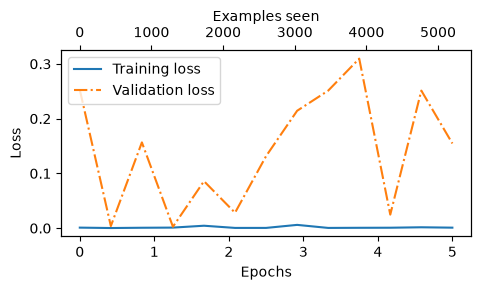

: 

In [ ]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

ochestrator.plot_values(epochs_seen=epochs_tensor,
                        examples_seen=examples_seen_tensor,
                        train_values=train_losses,
                        val_values=val_losses,
                        label="loss")